<a href="https://colab.research.google.com/github/scxbbard/Data-science-classes/blob/main/TelcoCustomerChurnProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#1. BUSINESS UNDERSTANDING
- Problem: which customers are likely to churn, and what's driving it?
- Objectives:

              (1) predict at-risk customers

              (2) explain the key drivers

              (3) turn drivers into retention actions
- Success criteria: because ~73% of customers do NOT churn, raw accuracy
 is misleading (predicting "No" for everyone scores ~73% while catching
zero churners). Success = recall/F1 on the churn class + actionability.
- Stakeholders: Retention/CRM team, Marketing, Finance, Executive sponsor

------------------------------------------------------------------------

Dataset: IBM/Kaggle Telco Customer Churn (7,043 customers x 21 attributes)

        - https://www.kaggle.com/datasets/blastchar/telco-customer-churn




# Structure (CRISP-DM):
 1. Business Understanding  
 2. Data Understanding  
 3. Data Preparation
 4. EDA  
 5. Modeling  
 6. Evaluation  
 7. Conclusions
 8. Limitations

#2. DATA UNDERSTANDING

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)

In [ ]:
RANDOM_STATE = 42
sns.set_style("darkgrid")
plt.rcParams["figure.dpi"] = 100

In [ ]:
# Load the data.
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# --- Structural checks ---
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()

Shape: 7043 rows, 21 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBill

In [ ]:
# Descriptive statistics for the numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
# Missing values per column
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0]
      if missing.sum() > 0
      else "None detected by isna() -- but see note below.")

Missing values per column:
None detected by isna() -- but see note below.


In [ ]:
# NOTE: TotalCharges is loaded as an 'object' (string) column, not numeric.
# A handful of rows store it as a blank string " " instead of a real missing value,
# so pandas' isna() won't catch them yet -- we fix this in Data Preparation below.
print(f"\nColumn dtypes show the issue:\n{df.dtypes[['tenure', 'MonthlyCharges', 'TotalCharges']]}")


Column dtypes show the issue:
tenure              int64
MonthlyCharges    float64
TotalCharges       object
dtype: object


In [ ]:
# Duplicate rows
print(f"\nFully duplicated rows: {df.duplicated().sum()}")


Fully duplicated rows: 0


In [ ]:
# Target class balance -- matters a lot for how we choose evaluation metrics later
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


- Observations to confirm on the full dataset: 7,043 rows x 21 columns,
- no full duplicates
- TotalCharges has 11 blank-string rows (tenure==0)
- target is imbalanced ~73% No / 27% Yes.


# 3. DATA PREPARATION
## Steps & why:
1. Fix TotalCharges -> numeric; resulting NaNs are the 11 tenure==0 customers -> drop
2. Drop duplicate rows, if any
3. Drop customerID -- unique identifier, zero predictive value, don't encode it
4. Encode target to 0/1
5. Feature engineering: tenure_group bucket + num_services count
6. One-hot encode categoricals (NOT LabelEncoder -- that imposes a false order
   on nominal categories like PaymentMethod)
7. Stratified train/test split (preserves churn ratio given the imbalance)
8. Scale only numeric columns (one-hot columns are already 0/1)


### 3.1 Fix TotalCharges

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_missing = df['TotalCharges'].isna().sum()
print(f"Rows with unparsable TotalCharges (new customers, tenure=0): {n_missing}")

df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

Rows with unparsable TotalCharges (new customers, tenure=0): 11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


### 3.2 Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

### 3.3 Drop the non-predictive identifie

In [ ]:
df = df.drop(columns=['customerID'])

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


###3.4 Encode target

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"\nFinal shape after cleaning: {df.shape}")


Final shape after cleaning: (7032, 20)


###3.5 Feature engineering

In [ ]:
df['tenure_group'] = pd.cut(
    df['tenure'], bins=[0, 12, 24, 48, 60, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5-6yr'], include_lowest=True
)

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

df[['tenure', 'tenure_group', 'num_services']].head()

,tenure,tenure_group,num_services
0,1,0-1yr,1
1,34,2-4yr,2
2,2,0-1yr,2
3,45,2-4yr,3
4,2,0-1yr,0


###3.6 Split features / target, then one-hot encode categoricals

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"\nShape after one-hot encoding: {X_encoded.shape}")


Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']

Shape after one-hot encoding: (7032, 35)


###3.7 Train/test split (stratified) + 3.8 scale numeric columns only

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2,random_state = RANDOM_STATE, stratify=y
)
print("Train churn rate:", round(y_train.mean(), 5), " | Test churn rate:", round(y_test.mean(), 5))

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


Train churn rate: 0.26578  | Test churn rate: 0.26581


# 4. EXPLORATORY DATA ANALYSIS

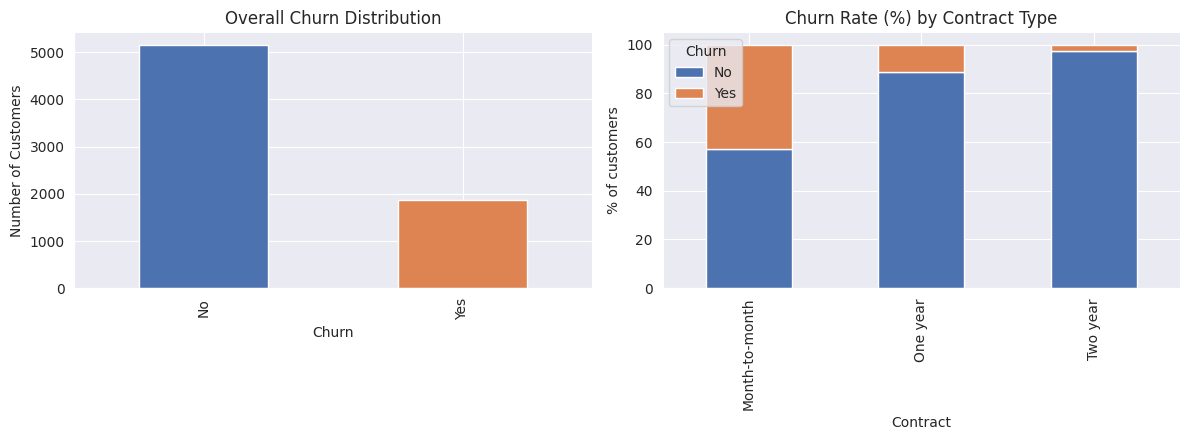

In [ ]:
# Overall churn rate, and churn rate by contract type
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df['Churn'].map({0: 'No', 1: 'Yes'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Overall Churn Distribution')
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Number of Customers')

pd.crosstab(df['Contract'], df['Churn'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Churn Rate (%) by Contract Type')
axes[1].set_ylabel('% of customers'); axes[1].legend(['No', 'Yes'], title='Churn')
plt.tight_layout()
plt.show()

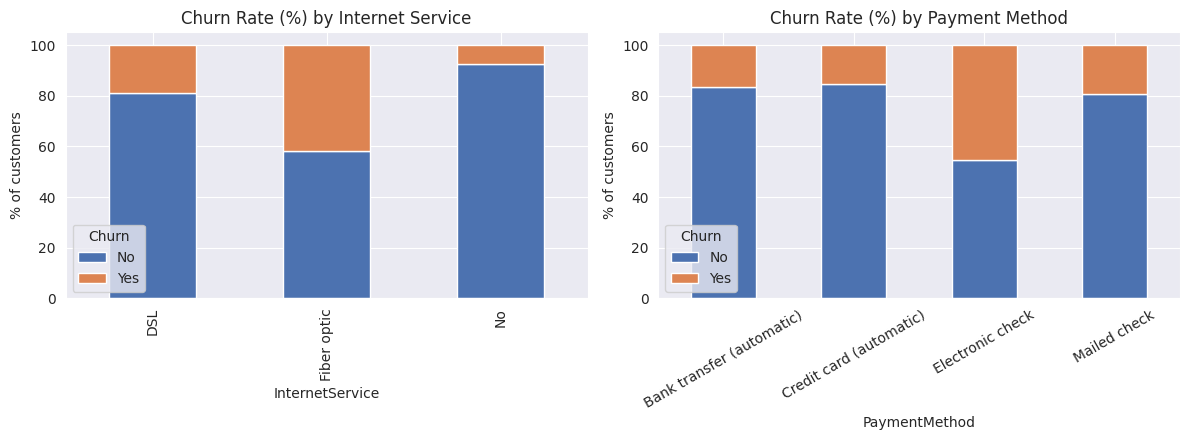

In [ ]:
# Churn rate by internet service type and payment method
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

pd.crosstab(df['InternetService'], df['Churn'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Churn Rate (%) by Internet Service')
axes[0].set_ylabel('% of customers'); axes[0].legend(['No', 'Yes'], title='Churn')

pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Churn Rate (%) by Payment Method')
axes[1].set_ylabel('% of customers'); axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(['No', 'Yes'], title='Churn')
plt.tight_layout()
plt.show()

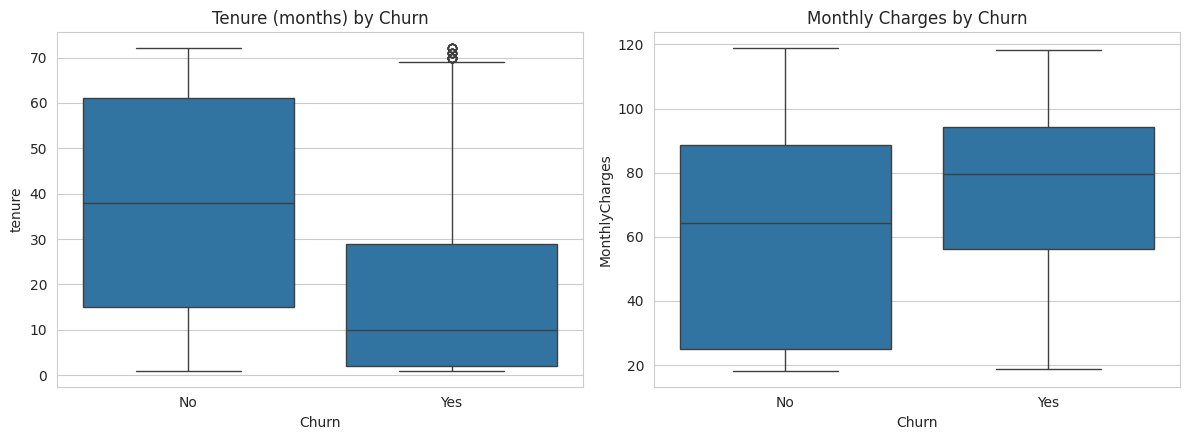

In [ ]:
# Tenure and MonthlyCharges distributions, split by churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['No', 'Yes'])
axes[0].set_title('Tenure (months) by Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['No', 'Yes'])
axes[1].set_title('Monthly Charges by Churn')
plt.tight_layout()
plt.show()

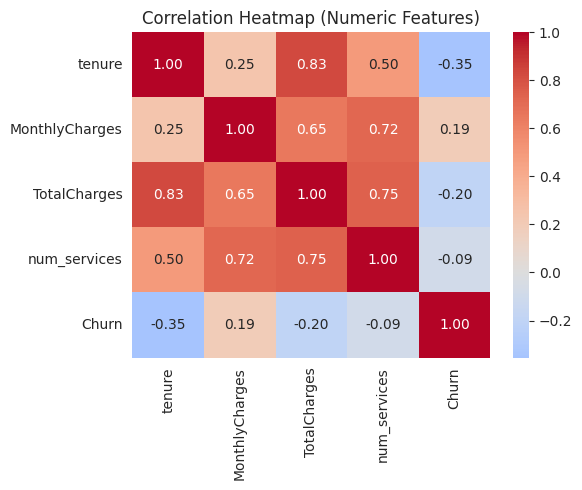

In [ ]:
# Correlation heatmap of the numeric features (post feature-engineering)
numeric_for_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'Churn']]
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


- EDA patterns to check for on the full dataset: contract type is usually the
- strongest driver (month-to-month churns far more); fiber optic often churns
- more than DSL despite higher price; low tenure = highest risk window;
- electronic-check payers churn more than automatic-payment customers.


# 5. MODELING
Logistic Regression (interpretable),
Random Forest (importances,non-linear),
Gradient Boosting (strong tabular baseline). class_weight='balanced' handles the imbalance; 5-fold stratified CV gives a morerobust estimate than a single train/test split.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_models = {}

for name, model in models.items():
    cv_f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "CV F1 (mean)": round(cv_f1.mean(), 3),
        "Test Accuracy": round(accuracy_score(y_test, preds), 3),
        "Test Precision": round(precision_score(y_test, preds), 3),
        "Test Recall": round(recall_score(y_test, preds), 3),
        "Test F1": round(f1_score(y_test, preds), 3),
        "Test ROC-AUC": round(roc_auc_score(y_test, proba), 3),
    })
    fitted_models[name] = model
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=['No Churn', 'Churn'], zero_division=0))

results_df = pd.DataFrame(results).sort_values('Test F1', ascending=False)
results_df

--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.72      0.74      1407

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

--- Gradient Boosting ---
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      140

,Model,CV F1 (mean),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.629,0.724,0.488,0.789,0.603,0.835
2,Gradient Boosting,0.577,0.795,0.638,0.532,0.580,0.841
1,Random Forest,0.548,0.785,0.623,0.487,0.547,0.817


#5.1 Hyperparameter tuning (Random Forest)

In [ ]:
# Optimizing for F1, not accuracy, since that's what matters for an imbalanced target.
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 8, 12, 16],
    'min_samples_leaf': [1, 2, 4],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid, cv=cv, scoring='f1', n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 3))

best_rf = grid.best_estimator_
best_preds = best_rf.predict(X_test_scaled)
print("\nTuned Random Forest — test set performance:")
print(classification_report(y_test, best_preds, target_names=['No Churn', 'Churn'], zero_division=0))

Best params: {'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 300}
Best CV F1: 0.639

Tuned Random Forest — test set performance:
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1033
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



# 6. MODEL EVALUATION

- Why not just accuracy? ~73% of customers don't churn, so a model that
 always predicts "No" scores ~73% accuracy while catching zero churners.
- Lead with recall/precision/F1/ROC-AUC instead.

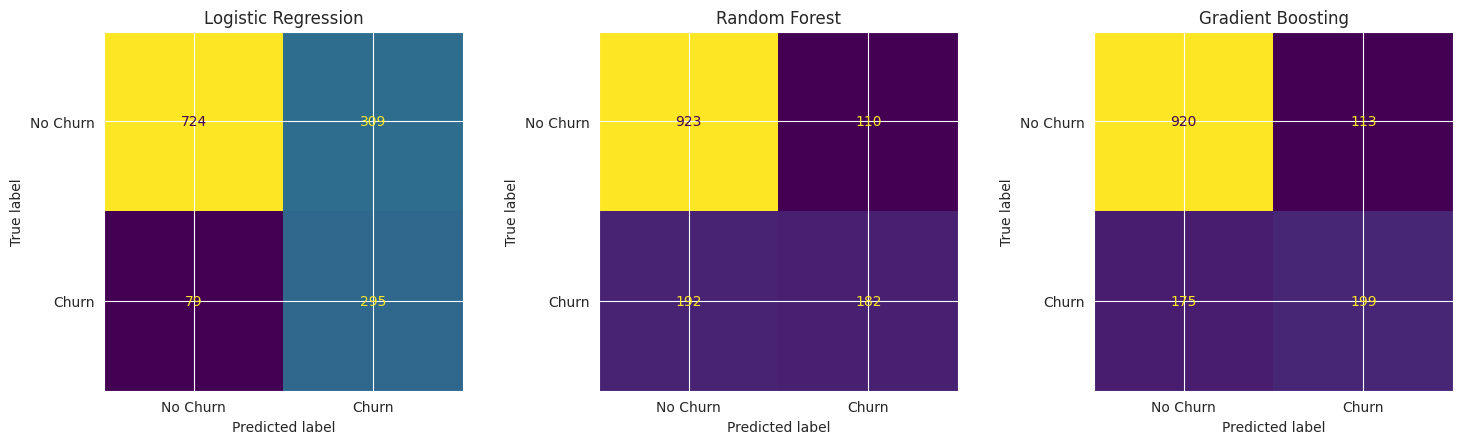

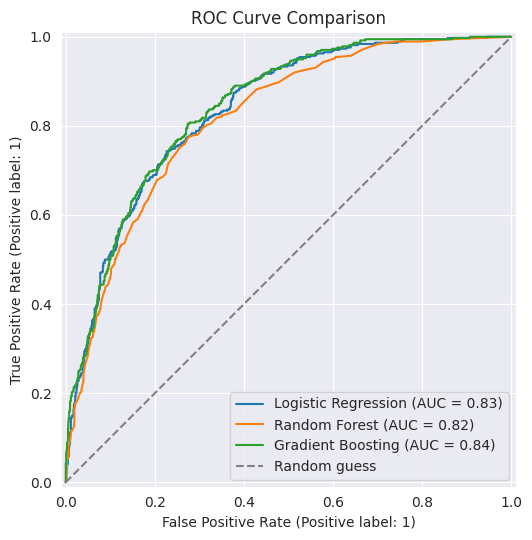

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, model) in zip(axes, fitted_models.items()):
    preds = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

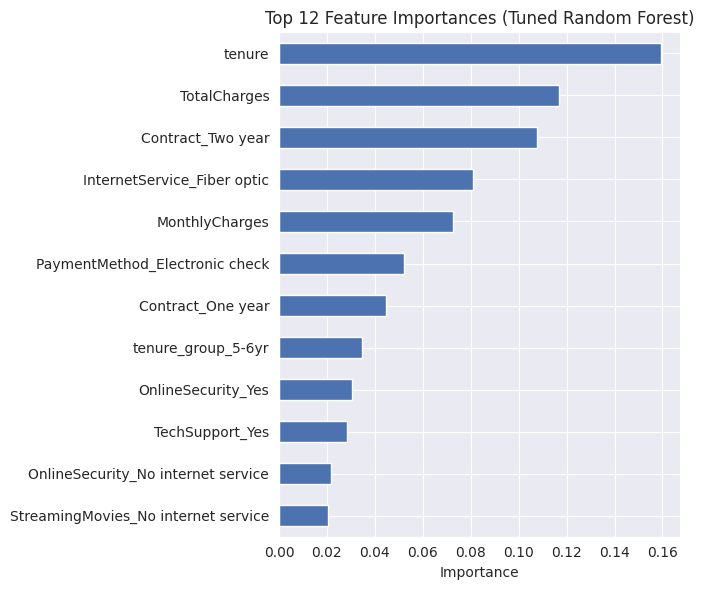

,0
tenure,0.159353
TotalCharges,0.116922
Contract_Two year,0.107620
InternetService_Fiber optic,0.081152
MonthlyCharges,0.072479
PaymentMethod_Electronic check,0.052156
Contract_One year,0.044694
tenure_group_5-6yr,0.034695
OnlineSecurity_Yes,0.030547
TechSupport_Yes,0.028261


In [ ]:
# Feature importance from the tuned Random Forest -- tells the retention
# team WHAT to act on, not just WHO to target.
importances = pd.Series(best_rf.feature_importances_, index=X_train_scaled.columns)
top_features = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(7, 6))
top_features.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 12 Feature Importances (Tuned Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_features

# 6.1 Model selection: compare results_df against the tuned RF's test
# metrics, and pick based on F1/recall for the churn class -- not accuracy.

# Recommended actions:
 - Contract incentives: discount for month-to-month -> 1-year upgrade,
  especially in the first 3 months
 - Onboarding push: offer add-on services in month 1-2
 - Payment friction: investigate/incentivize a move off electronic check
 - Fiber optic experience: review pricing/quality complaints
 - Targeted list: rank by predicted churn probability x customer LTV


#8. LIMITATIONS & FUTURE WORK
 - Snapshot data: doesn't capture behavior changes over time
 - Class imbalance: could also try SMOTE or cost-sensitive thresholds
 - No cost model: F1 isn't the same as $ saved -- incorporate customer LTV
 - Time-based validation would be more rigorous than a random split
 - If deployed, monitor for performance drift over time


# 7. CONCLUSIONS & BUSINESS RECOMMENDATIONS
- (Fill in your own run's numbers -- these bullets reflect the patterns
- this dataset consistently shows; confirm before presenting.)
- Key churn drivers: contract type (month-to-month churns most), tenure

  -(first 12 months = highest risk), internet service/payment method

  -(fiber optic + electronic check show elevated churn), num_services

  -(fewer add-ons = more churn, i.e. under-engaged customers leave more).
